# Capstone Function 1
Detect likely contamination source in a two-dimensional area, such as a radiation field, where only proximity yeilds a non-zero reading.  The system uses Bayesian Optimization to tune detection parameters and reliably identify both strong and weak sources
| Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

## Notes
- Inputs are in range 0 to 1
- outputs very small - 0 if not close the source
-

## Initial Submission

This section contains the initial Bayesian Optimization implementation using BoTorch with Gaussian Process surrogate model and Expected Improvement acquisition function.

### Step 1: Import Required Libraries

Import necessary libraries for Bayesian Optimization, data handling, and visualization.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

### Step 2: Load and Display Initial Data

Load the initial input and output data for the radiation source detection problem.

In [ ]:
# Load initial data
X_init = np.load('../../data/f1/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f1/updated_outputs - Week 4.npy')

# Display data characteristics
print("Initial Data Summary:")
print(f"Input shape: {X_init.shape}")
print(f"Output shape: {y_init.shape}")
print(f"\nInput range: [{X_init.min():.4f}, {X_init.max():.4f}]")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")
print(f"Output mean: {y_init.mean():.6f}")
print(f"Output std: {y_init.std():.6f}")
print(f"\nBest observed value: {y_init.max():.6f}")
print(f"Best input location: {X_init[y_init.argmax()]}")

# Display first few samples
print(f"\nFirst 5 samples:")
for i in range(min(5, len(X_init))):
    print(f"  X[{i}] = {X_init[i]}, y[{i}] = {y_init[i]:.6f}")

In [ ]:
# Visualize initial data points in 2D space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_init[:, 0], X_init[:, 1], c=y_init, s=200, cmap='viridis', edgecolors='black', linewidth=1.5)
plt.colorbar(scatter, label='Output Value')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Initial Data Points - Radiation Source Detection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark the best point
best_idx = y_init.argmax()
plt.scatter(X_init[best_idx, 0], X_init[best_idx, 1], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label=f'Best (y={y_init[best_idx]:.6f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Step 3: Define Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Gaussian Process Kernel**: Matern 5/2 (BoTorch default)
   - **Why**: Provides a good balance between smoothness and flexibility for unknown functions
   - Suitable for radiation fields which may have smooth gradients near sources

2. **Acquisition Function**: Expected Improvement (EI)
   - **Why**: Simple, well-tested, and effective for maximization
   - Balances exploration (searching new areas) and exploitation (refining known good areas)
   - Works well with small sample sizes (10 initial points)

3. **Number of Restarts for Acquisition Optimization**: 10
   - **Why**: Ensures we find good candidates by starting from multiple random points
   - Important for avoiding local optima in acquisition function

4. **Number of Raw Samples**: 512
   - **Why**: Initial random sampling to find good starting points for optimization
   - Higher number increases chances of finding global optimum of acquisition function

5. **Input Bounds**: [0, 1.0] for all dimensions
   - **Why**: Required by submission format - all inputs must be in range [0, 1.0]

6. **Standardize Outputs**: Yes
   - **Why**: Outputs are very small (close to 0 when far from source)
   - Standardization helps GP model training and numerical stability

In [ ]:
# Define hyperparameters
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]  # Number of dimensions
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)
NUM_RESTARTS = 10  # Number of restarts for acquisition function optimization
RAW_SAMPLES = 512  # Number of initial random samples for acquisition optimization

print("Hyperparameters:")
print(f"  Input bounds: [0, 1.0] for all {N_DIM} dimensions")
print(f"  Acquisition function: Expected Improvement (EI)")
print(f"  GP Kernel: Matern 5/2 (default)")
print(f"  Number of restarts: {NUM_RESTARTS}")

print(f"  Raw samples: {RAW_SAMPLES}")
print(f"  Output standardization: Yes (SingleTaskGP handles this)")

### Step 4: Build Gaussian Process Surrogate Model

Create and train a Gaussian Process model on the initial data. The GP learns the relationship between inputs and outputs.

In [ ]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)  # Add dimension for single output

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Create Gaussian Process model
# SingleTaskGP automatically standardizes outputs for better numerical stability
gp_model = SingleTaskGP(X_train, y_train)

# Define the marginal log likelihood
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)

# Fit the GP model to the data
print("\nTraining Gaussian Process model...")
fit_gpytorch_mll(mll)
print("✓ Model training complete!")

# Display learned hyperparameters
print("\nLearned GP Hyperparameters:")
print(f"  Noise variance: {gp_model.likelihood.noise.item():.6f}")
# Check if covar_module has outputscale (ScaleKernel) or is base kernel directly
if hasattr(gp_model.covar_module, 'outputscale'):
    print(f"  Output scale: {gp_model.covar_module.outputscale.item():.6f}")
    print(f"  Length scales: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
else:
    # Direct access to kernel lengthscale
    print(f"  Length scales: {gp_model.covar_module.lengthscale.detach().numpy()}")

### Step 5: Optimize Acquisition Function to Propose Next Sample

Use Expected Improvement to find the next most promising point to evaluate.

In [ ]:
# Create Expected Improvement acquisition function
# best_f is the best observed value so far
best_f = y_train.max().item()
print(f"Best observed value: {best_f:.6f}")

EI = ExpectedImprovement(gp_model, best_f=best_f)

# Optimize the acquisition function to find the next candidate point
print("\nOptimizing acquisition function...")
candidate, acq_value = optimize_acqf(
    EI,
    bounds=BOUNDS,
    q=1,  # Number of candidates to generate
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

# Extract the proposed next point
next_point = candidate.detach().numpy()[0]
print("✓ Optimization complete!")
print(f"\nProposed next sample point:")
print(f"  X_next = {next_point}")
print(f"  Expected Improvement value: {acq_value.item():.6f}")

### Step 6: Visualize Surrogate Function

Visualize the GP mean prediction and uncertainty across the 2D search space.

In [ ]:
# Create a grid for visualization
n_grid = 50
x1 = np.linspace(0, 1, n_grid)
x2 = np.linspace(0, 1, n_grid)
X1_grid, X2_grid = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_grid_torch = torch.tensor(X_grid, dtype=torch.float64)

# Get GP predictions
gp_model.eval()
with torch.no_grad():
    posterior = gp_model.posterior(X_grid_torch)
    mean = posterior.mean.numpy().reshape(n_grid, n_grid)
    std = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: GP Mean Prediction
im1 = axes[0].contourf(X1_grid, X2_grid, mean, levels=20, cmap='viridis')
axes[0].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[0].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('GP Mean Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Predicted Value')

# Plot 2: GP Uncertainty (Standard Deviation)
im2 = axes[1].contourf(X1_grid, X2_grid, std, levels=20, cmap='plasma')
axes[1].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[1].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('GP Uncertainty (Std Dev)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Standard Deviation')

plt.tight_layout()
plt.show()

print(f"The GP predicts highest values near regions with observed high outputs.")
print(f"Uncertainty is highest in unexplored regions.")

### Step 7: Visualize Acquisition Function

Show the Expected Improvement values across the search space, indicating where the algorithm wants to sample next.

In [ ]:
# Compute Expected Improvement values across the grid
with torch.no_grad():
    ei_values = EI(X_grid_torch.unsqueeze(1)).numpy().reshape(n_grid, n_grid)

# Visualize Expected Improvement
plt.figure(figsize=(10, 8))
im = plt.contourf(X1_grid, X2_grid, ei_values, levels=20, cmap='hot')
plt.scatter(X_init[:, 0], X_init[:, 1], c='cyan', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
plt.scatter(next_point[0], next_point[1], c='lime', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point (max EI)', zorder=6)
plt.colorbar(im, label='Expected Improvement')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Expected Improvement Acquisition Function', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The next point is selected where Expected Improvement is maximized.")
print(f"This balances exploring uncertain regions and exploiting promising areas.")

### Step 8: Track Optimization Progress

Monitor the best observed value over iterations to assess convergence.

In [ ]:
# Track the best value found so far at each iteration
best_observed = np.maximum.accumulate(y_init)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_observed) + 1), best_observed, 'b-o', linewidth=2, markersize=8, label='Best observed value')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Objective Value', fontsize=12)
plt.title('Optimization Progress - Best Value Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Starting best value: {y_init.max():.6f}")
print(f"After {len(y_init)} initial samples, awaiting next evaluation...")
print(f"\nNext submission: {next_point}")

### Step 9: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

### Summary

**Initial Submission Complete**

- Loaded 10 initial data points for 2D radiation source detection
- Built Gaussian Process surrogate model with Matern 5/2 kernel
- Used Expected Improvement acquisition function
- Proposed next sample point for evaluation
- Visualized surrogate function, uncertainty, and acquisition landscape

**Next Steps:**
1. Submit the proposed point for evaluation
2. Receive the observation result
3. Add to dataset and retrain model
4. Propose next point (repeat process)

The optimization is designed to efficiently locate radiation sources by balancing exploration of the 2D space with exploitation of promising regions showing non-zero readings.

## Week 5 — Polynomial Response Surface

This section replaces the Gaussian Process surrogate with a **Quadratic Polynomial Response Surface** to demonstrate an alternative modelling approach.

**Why Polynomial for f1?**
- f1 is 2-dimensional — a quadratic polynomial in 2D has only 6 coefficients (1 + 2 linear + 2 squared + 1 interaction), which is manageable with 15 data points
- Polynomial models are interpretable: each coefficient directly shows the effect of an input variable
- Fast to fit and evaluate — no iterative optimization needed

**Acquisition Strategy:** Upper Confidence Bound (UCB) instead of Expected Improvement, since polynomials don't provide native uncertainty estimates like GPs do. Uncertainty is estimated via distance from observed points.

### Step 1: Load Week 5 Data

Load the cumulative Week 5 data (initial 10 samples + 5 weekly submissions = 15 total).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from scipy.spatial.distance import cdist

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f1/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f1/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Input range:  [{X_w5.min():.6f}, {X_w5.max():.6f}]")
print(f"Output range: [{y_w5.min():.6e}, {y_w5.max():.6e}]")
print(f"Best observed value: {y_w5.max():.6e} at index {y_w5.argmax()}")
print(f"Best observed point: [{X_w5[y_w5.argmax()][0]:.6f}, {X_w5[y_w5.argmax()][1]:.6f}]")

Week 5 Data: 15 samples, 2 dimensions
Input range:  [0.060194, 0.986619]
Output range: [-3.606063e-03, 7.710875e-16]
Best observed value: 7.710875e-16 at index 2
Best observed point: [0.731024, 0.733000]


### Step 2: Polynomial Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Polynomial Degree = 2 (Quadratic)**: A quadratic polynomial in 2D produces 6 coefficients: intercept, x₁, x₂, x₁², x₂², x₁·x₂. With 15 data points we have a 2.5:1 sample-to-coefficient ratio — sufficient to fit without severe overfitting. Higher degrees (cubic = 10 coefficients) would reduce this ratio to 1.5:1 which risks unreliable fits.

2. **Ridge Regularization (α = 0.01)**: Small but non-zero regularization to prevent coefficient inflation when data points are clustered. Ridge is preferred over plain LinearRegression because with only 15 samples, even quadratic features can produce multicollinearity. α = 0.01 provides light regularization without dominating the fit.

3. **UCB Exploration Parameter (κ = 1.5)**: Controls the exploration-exploitation tradeoff. For the polynomial model, uncertainty σ(x) is measured by distance from the nearest observed point (range ~0 to 0.7 in normalised [0,1]² space). κ = 1.5 means we add up to ~1× the output range in exploration bonus at the most distant point, providing moderate exploration. Lower than 2.0 because distance-based σ tends to overestimate uncertainty compared to probabilistic methods.

4. **Number of UCB candidates = 20,000**: Random points sampled uniformly in [0, 1.0]². Sufficient coverage for 2D — each point occupies roughly 1/20000 of the unit square (~0.007 resolution).

In [2]:
# --- Polynomial Hyperparameters ---
POLY_DEGREE = 2          # Quadratic polynomial (6 coefficients for 2D)
RIDGE_ALPHA = 0.01       # Light Ridge regularization to prevent coefficient inflation
KAPPA = 1.5              # UCB exploration parameter (tuned for distance-based uncertainty)
N_CANDIDATES = 20000     # Number of random UCB candidate points

print("Polynomial Surrogate Hyperparameters:")
print(f"  Polynomial degree:    {POLY_DEGREE}")
print(f"  Ridge alpha:          {RIDGE_ALPHA}")
print(f"  UCB kappa:            {KAPPA}")
print(f"  UCB candidates:       {N_CANDIDATES}")
print(f"  Expected coefficients: {int((POLY_DEGREE + 1) * (POLY_DEGREE + 2) / 2)} (for 2D degree-{POLY_DEGREE})")
print(f"  Sample/coefficient ratio: {X_w5.shape[0] / ((POLY_DEGREE + 1) * (POLY_DEGREE + 2) / 2):.1f}:1")

Polynomial Surrogate Hyperparameters:
  Polynomial degree:    2
  Ridge alpha:          0.01
  UCB kappa:            1.5
  UCB candidates:       20000
  Expected coefficients: 6 (for 2D degree-2)
  Sample/coefficient ratio: 2.5:1


### Step 3: Fit Polynomial Response Surface

Fit a quadratic polynomial using `PolynomialFeatures` to generate interaction terms, then `Ridge` regression with light regularisation. Display all coefficients with their feature labels, the R² score, and intercept.

In [3]:
# Generate quadratic polynomial features: [1, x1, x2, x1^2, x1*x2, x2^2]
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)
X_poly = poly.fit_transform(X_w5)

# Fit Ridge regression
model = Ridge(alpha=RIDGE_ALPHA)
model.fit(X_poly, y_w5)

# Display results
feature_names = poly.get_feature_names_out(['x1', 'x2'])
r2_score = model.score(X_poly, y_w5)

print("Polynomial Response Surface Coefficients:")
print(f"  Intercept: {model.intercept_:.6e}")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name:>10s}: {coef:.6e}")
print(f"\nR² Score: {r2_score:.6f}")
print(f"Number of coefficients: {len(model.coef_) + 1} (including intercept)")

Polynomial Response Surface Coefficients:
  Intercept: 7.307656e-04
          x1: -2.261578e-03
          x2: -3.063451e-03
        x1^2: 3.461631e-03
       x1 x2: -2.875350e-03
        x2^2: 4.227482e-03

R² Score: 0.172394
Number of coefficients: 6 (including intercept)


### Step 4: UCB Acquisition Function

Since polynomial models don't provide native uncertainty estimates, we use a **distance-based uncertainty** approach:
- **σ(x)** = minimum Euclidean distance from candidate point x to the nearest observed data point, normalized by the maximum such distance across all candidates
- **UCB(x) = μ(x) + κ · σ(x)** — balances exploiting the polynomial prediction (μ) with exploring regions far from observed data (σ)

This encourages sampling in under-explored regions while still favouring areas where the polynomial predicts high values.

In [4]:
# Generate random candidate points in [0, 1.0]^2
np.random.seed(42)  # Reproducibility
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 2))

# Compute polynomial predictions (mean) for all candidates
candidates_poly = poly.transform(candidates)
mu = model.predict(candidates_poly)

# Compute distance-based uncertainty: min distance from each candidate to nearest observed point
distances = cdist(candidates, X_w5)       # shape: (N_CANDIDATES, 15)
min_distances = distances.min(axis=1)      # shape: (N_CANDIDATES,)

# Normalize uncertainty to [0, 1] so κ has consistent meaning
sigma = min_distances / min_distances.max()

# Normalize mu to [0, 1] range so UCB terms are comparable
mu_range = mu.max() - mu.min()
if mu_range > 0:
    mu_norm = (mu - mu.min()) / mu_range
else:
    mu_norm = np.zeros_like(mu)

# UCB acquisition: balance exploitation (mu) with exploration (sigma)
ucb = mu_norm + KAPPA * sigma

# Select the candidate with the highest UCB value
best_idx = np.argmax(ucb)
next_point_w5 = candidates[best_idx]

# Clamp to valid range
next_point_w5 = np.clip(next_point_w5, 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  Mean prediction:    {mu[best_idx]:.6e} (normalised: {mu_norm[best_idx]:.6f})")
print(f"  Uncertainty (dist): {sigma[best_idx]:.6f}")
print(f"  Next sample point:  [{next_point_w5[0]:.6f}, {next_point_w5[1]:.6f}]")

UCB Acquisition Results:
  Best UCB value:     2.481562
  Mean prediction:    1.871815e-03 (normalised: 0.981562)
  Uncertainty (dist): 1.000000
  Next sample point:  [0.003918, 0.999460]


### Step 5: Visualize Polynomial Surrogate Function

Display the polynomial response surface as a contour plot over the full [0,1]² search space, with observed data points overlaid. Also show the distance-based uncertainty surface.

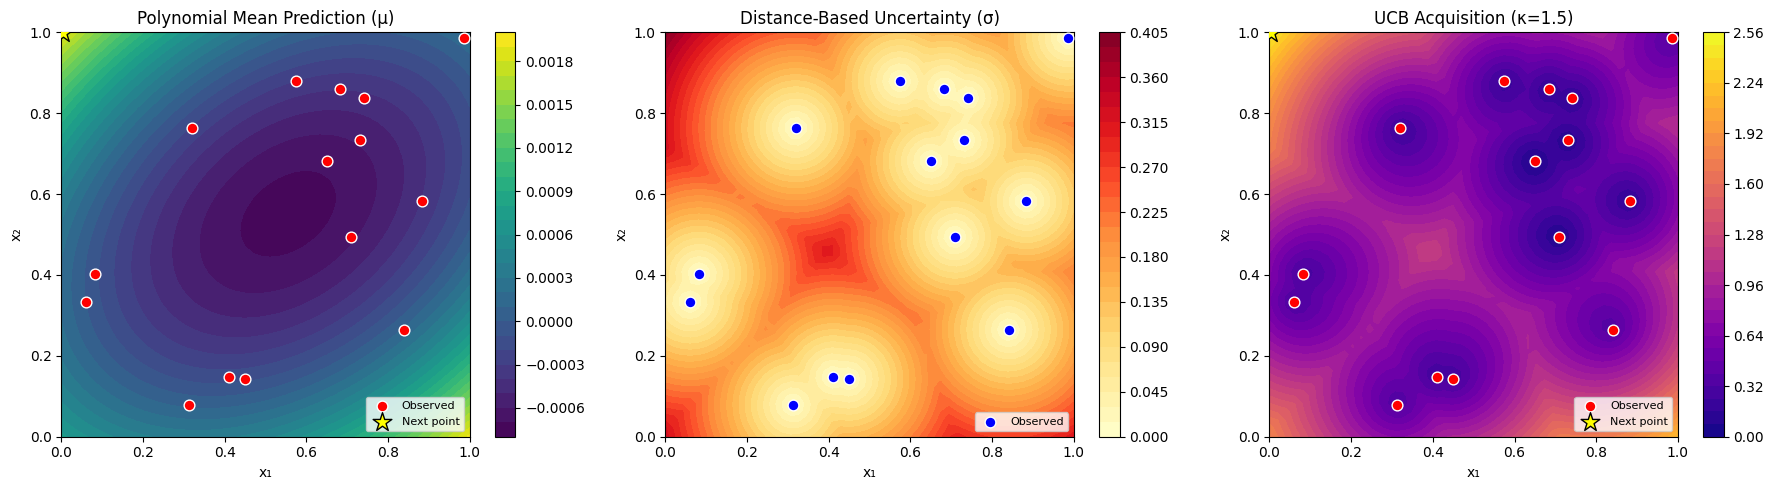

In [5]:
# Create evaluation grid for visualization
n_grid = 50
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

# Polynomial predictions on the grid
grid_poly = poly.transform(grid_points)
grid_mu = model.predict(grid_poly).reshape(n_grid, n_grid)

# Distance-based uncertainty on the grid
grid_distances = cdist(grid_points, X_w5)
grid_sigma = grid_distances.min(axis=1).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Polynomial mean prediction
ax1 = axes[0]
c1 = ax1.contourf(X1, X2, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, 0], X_w5[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[0], next_point_w5[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Polynomial Mean Prediction (μ)')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Distance-based uncertainty
ax2 = axes[1]
c2 = ax2.contourf(X1, X2, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, 0], X_w5[:, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Distance-Based Uncertainty (σ)')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: UCB acquisition surface
grid_mu_norm = (grid_mu - grid_mu.min()) / (grid_mu.max() - grid_mu.min()) if grid_mu.max() != grid_mu.min() else np.zeros_like(grid_mu)
grid_sigma_norm = grid_sigma / grid_sigma.max() if grid_sigma.max() > 0 else np.zeros_like(grid_sigma)
grid_ucb = grid_mu_norm + KAPPA * grid_sigma_norm

ax3 = axes[2]
c3 = ax3.contourf(X1, X2, grid_ucb, levels=30, cmap='plasma')
ax3.scatter(X_w5[:, 0], X_w5[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax3.scatter(next_point_w5[0], next_point_w5[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_title(f'UCB Acquisition (κ={KAPPA})')
ax3.legend(loc='lower right', fontsize=8)
plt.colorbar(c3, ax=ax3)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Track the running maximum (best observed value) across all 15 observations to visualize optimization progress.

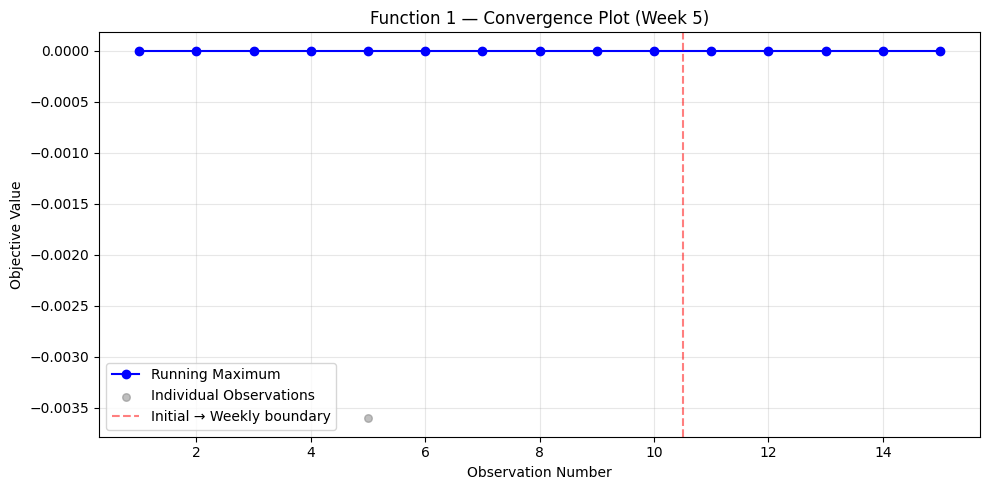

Best observed value: 7.710875e-16
Achieved at observation: 3


In [6]:
# Convergence plot: running maximum over all observations
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 1 — Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6e}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point in the required submission format: `x1-x2` with 6 decimal places, clamped to [0, 1.0].

In [7]:
# Format submission query
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"Surrogate: Polynomial Response Surface (Quadratic)")
print(f"Acquisition: UCB (κ={KAPPA})")
print(f"Next point: [{next_point_w5[0]:.6f}, {next_point_w5[1]:.6f}]")
print(f"Polynomial prediction at next point: {mu[best_idx]:.6e}")
print(f"Distance-based uncertainty: {sigma[best_idx]:.6f}")
print(f"UCB value: {ucb[best_idx]:.6f}")
print(f"\n>>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 1
Surrogate: Polynomial Response Surface (Quadratic)
Acquisition: UCB (κ=1.5)
Next point: [0.003918, 0.999460]
Polynomial prediction at next point: 1.871815e-03
Distance-based uncertainty: 1.000000
UCB value: 2.481562

>>> SUBMISSION: 0.003918-0.999460


### Model Comparison

**Polynomial vs GP (Initial Section):**
- The GP model from the initial submission uses a Matern 5/2 kernel with Expected Improvement acquisition. It learns a smooth probabilistic surface with native uncertainty quantification.
- The polynomial model approximates the surface with a fixed functional form (6 coefficients). It cannot capture local structure but is fully interpretable.
- For f1's radiation detection problem (very small output values near zero, with a sharp peak), a polynomial is likely too smooth to capture the localized source — but it provides useful complementary exploration by favouring broad coverage of the space through distance-based uncertainty.
- Both models should agree that the region near the best observed point (~[0.73, 0.73]) is promising, though the polynomial's exploration will be more uniform.

## Week 6 — Polynomial Response Surface

This section continues the polynomial surrogate approach from Week 5 with an **increased exploration parameter** (κ raised from 1.5 to 3.0).

**Why increase κ for f1?**
- Week 5's polynomial fit yielded a low R² (~0.17), indicating the quadratic surface does not capture f1's structure well
- With poor model fidelity, trusting the mean prediction (μ) is risky — we should weight uncertainty (σ) more heavily
- κ=3.0 doubles the exploration bonus, encouraging UCB to propose points in under-explored regions rather than near the (unreliable) predicted optimum
- This is the opposite strategy from f2–f8, which use κ=0.5 for exploitation — f1 uniquely benefits from broader search

**Acquisition Strategy:** UCB with κ=3.0 and distance-based uncertainty, same as Week 5 but with stronger exploration weighting.

### Step 1: Load Week 6 Data

Load the cumulative Week 6 data (initial 10 samples + 6 weekly submissions = 16 total).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from scipy.spatial.distance import cdist

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f1/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f1/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Input range:  [{X_w6.min():.6f}, {X_w6.max():.6f}]")
print(f"Output range: [{y_w6.min():.6e}, {y_w6.max():.6e}]")
print(f"Best observed value: {y_w6.max():.6e} at index {y_w6.argmax()}")
print(f"Best observed point: [{X_w6[y_w6.argmax()][0]:.6f}, {X_w6[y_w6.argmax()][1]:.6f}]")

Week 6 Data: 16 samples, 2 dimensions
Input range:  [0.003918, 0.999460]
Output range: [-3.606063e-03, 7.710875e-16]
Best observed value: 7.710875e-16 at index 2
Best observed point: [0.731024, 0.733000]


### Step 2: Polynomial Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Polynomial Degree = 2 (Quadratic)**: Same as Week 5. With 16 data points and 6 coefficients, sample-to-coefficient ratio is 2.7:1 — adequate for stable fitting.

2. **Ridge Regularization (α = 0.01)**: Same as Week 5. Light regularization to prevent coefficient inflation.

3. **UCB Exploration Parameter (κ = 3.0)**: **Doubled from Week 5's κ=1.5**. Week 5's polynomial yielded low R² (~0.17), suggesting the quadratic model does not capture f1's true surface. Increasing κ amplifies the distance-based uncertainty term, shifting the acquisition function toward under-explored regions. At κ=3.0, uncertainty contributes ~2× more than the mean prediction at distant points.

4. **Number of UCB candidates = 20,000**: Same as Week 5, sufficient coverage for 2D.

In [10]:
# --- Polynomial Hyperparameters ---
POLY_DEGREE = 2          # Quadratic polynomial (6 coefficients for 2D)
RIDGE_ALPHA = 0.01       # Light Ridge regularization to prevent coefficient inflation
KAPPA = 3.0              # UCB exploration parameter (doubled from Week 5's 1.5)
N_CANDIDATES = 20000     # Number of random UCB candidate points

print("Polynomial Surrogate Hyperparameters:")
print(f"  Polynomial degree:    {POLY_DEGREE}")
print(f"  Ridge alpha:          {RIDGE_ALPHA}")
print(f"  UCB kappa:            {KAPPA} (Week 5: 1.5 → Week 6: 3.0)")
print(f"  UCB candidates:       {N_CANDIDATES}")
print(f"  Expected coefficients: {int((POLY_DEGREE + 1) * (POLY_DEGREE + 2) / 2)} (for 2D degree-{POLY_DEGREE})")
print(f"  Sample/coefficient ratio: {X_w6.shape[0] / ((POLY_DEGREE + 1) * (POLY_DEGREE + 2) / 2):.1f}:1")

Polynomial Surrogate Hyperparameters:
  Polynomial degree:    2
  Ridge alpha:          0.01
  UCB kappa:            3.0 (Week 5: 1.5 → Week 6: 3.0)
  UCB candidates:       20000
  Expected coefficients: 6 (for 2D degree-2)
  Sample/coefficient ratio: 2.7:1


### Step 3: Fit Polynomial Response Surface

Fit a quadratic polynomial using `PolynomialFeatures` to generate interaction terms, then `Ridge` regression with light regularisation. Display all coefficients with their feature labels, the R² score, and intercept.

In [11]:
# Generate quadratic polynomial features: [1, x1, x2, x1^2, x1*x2, x2^2]
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)
X_poly = poly.fit_transform(X_w6)

# Fit Ridge regression
model = Ridge(alpha=RIDGE_ALPHA)
model.fit(X_poly, y_w6)

# Display results
feature_names = poly.get_feature_names_out(['x1', 'x2'])
r2_score = model.score(X_poly, y_w6)

print("Polynomial Response Surface Coefficients:")
print(f"  Intercept: {model.intercept_:.6e}")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name:>10s}: {coef:.6e}")
print(f"\nR² Score: {r2_score:.6f}")
print(f"Number of coefficients: {len(model.coef_) + 1} (including intercept)")

Polynomial Response Surface Coefficients:
  Intercept: 7.443403e-04
          x1: -1.925688e-03
          x2: -2.802560e-03
        x1^2: 2.006226e-03
       x1 x2: -1.209025e-04
        x2^2: 2.279797e-03

R² Score: 0.117319
Number of coefficients: 6 (including intercept)


### Step 4: UCB Acquisition Function

Since polynomial models don't provide native uncertainty estimates, we use a **distance-based uncertainty** approach:
- **σ(x)** = minimum Euclidean distance from candidate point x to the nearest observed data point, normalized by the maximum such distance across all candidates
- **UCB(x) = μ_norm(x) + κ · σ(x)** — with κ=3.0, the uncertainty term dominates for distant points

With κ=3.0 (doubled from Week 5's 1.5), distant unexplored regions receive a much larger bonus, encouraging broad exploration despite the polynomial's low R².

In [12]:
# Generate random candidate points in [0, 1.0]^2
np.random.seed(42)  # Reproducibility
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 2))

# Compute polynomial predictions (mean) for all candidates
candidates_poly = poly.transform(candidates)
mu = model.predict(candidates_poly)

# Compute distance-based uncertainty: min distance from each candidate to nearest observed point
distances = cdist(candidates, X_w6)       # shape: (N_CANDIDATES, 16)
min_distances = distances.min(axis=1)      # shape: (N_CANDIDATES,)

# Normalize uncertainty to [0, 1] so κ has consistent meaning
sigma = min_distances / min_distances.max()

# Normalize mu to [0, 1] range so UCB terms are comparable
mu_range = mu.max() - mu.min()
if mu_range > 0:
    mu_norm = (mu - mu.min()) / mu_range
else:
    mu_norm = np.zeros_like(mu)

# UCB acquisition: balance exploitation (mu) with exploration (sigma)
# κ=3.0 heavily weights exploration — uncertainty contributes 3× more than mean
ucb = mu_norm + KAPPA * sigma

# Select the candidate with the highest UCB value
best_idx = np.argmax(ucb)
next_point_w6 = candidates[best_idx]

# Clamp to valid range
next_point_w6 = np.clip(next_point_w6, 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  Mean prediction:    {mu[best_idx]:.6e} (normalised: {mu_norm[best_idx]:.6f})")
print(f"  Uncertainty (dist): {sigma[best_idx]:.6f}")
print(f"  Exploration contribution (κ·σ): {KAPPA * sigma[best_idx]:.6f}")
print(f"  Next sample point:  [{next_point_w6[0]:.6f}, {next_point_w6[1]:.6f}]")

UCB Acquisition Results:
  Best UCB value:     3.940561
  Mean prediction:    7.349778e-04 (normalised: 0.940561)
  Uncertainty (dist): 1.000000
  Exploration contribution (κ·σ): 3.000000
  Next sample point:  [0.004402, 0.000330]


### Step 5: Visualize Polynomial Surrogate Function

Display the polynomial response surface as a contour plot over the full [0,1]² search space, with observed data points overlaid. Also show the distance-based uncertainty surface and the UCB acquisition surface with κ=3.0.

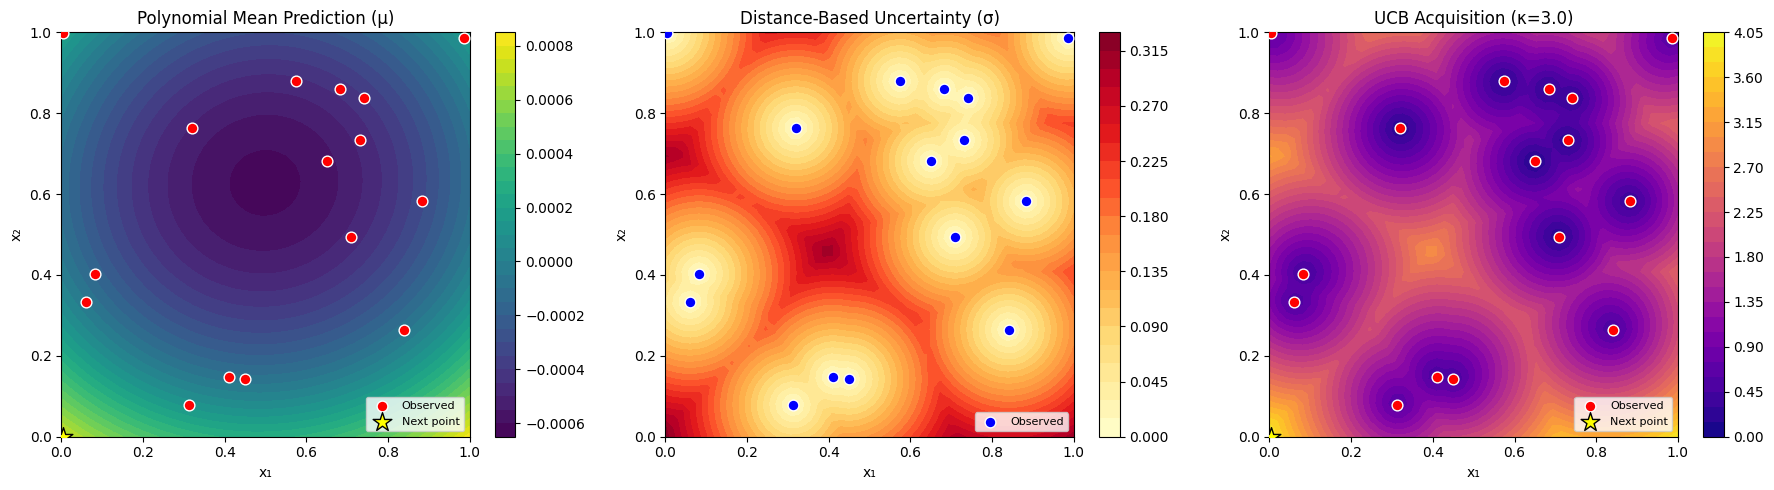

In [13]:
# Create evaluation grid for visualization
n_grid = 50
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

# Polynomial predictions on the grid
grid_poly = poly.transform(grid_points)
grid_mu = model.predict(grid_poly).reshape(n_grid, n_grid)

# Distance-based uncertainty on the grid
grid_distances = cdist(grid_points, X_w6)
grid_sigma = grid_distances.min(axis=1).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Polynomial mean prediction
ax1 = axes[0]
c1 = ax1.contourf(X1, X2, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w6[:, 0], X_w6[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w6[0], next_point_w6[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Polynomial Mean Prediction (μ)')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Distance-based uncertainty
ax2 = axes[1]
c2 = ax2.contourf(X1, X2, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w6[:, 0], X_w6[:, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Distance-Based Uncertainty (σ)')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: UCB acquisition surface
grid_mu_norm = (grid_mu - grid_mu.min()) / (grid_mu.max() - grid_mu.min()) if grid_mu.max() != grid_mu.min() else np.zeros_like(grid_mu)
grid_sigma_norm = grid_sigma / grid_sigma.max() if grid_sigma.max() > 0 else np.zeros_like(grid_sigma)
grid_ucb = grid_mu_norm + KAPPA * grid_sigma_norm

ax3 = axes[2]
c3 = ax3.contourf(X1, X2, grid_ucb, levels=30, cmap='plasma')
ax3.scatter(X_w6[:, 0], X_w6[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax3.scatter(next_point_w6[0], next_point_w6[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_title(f'UCB Acquisition (κ={KAPPA})')
ax3.legend(loc='lower right', fontsize=8)
plt.colorbar(c3, ax=ax3)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Track the running maximum (best observed value) across all 16 observations to visualize optimization progress.

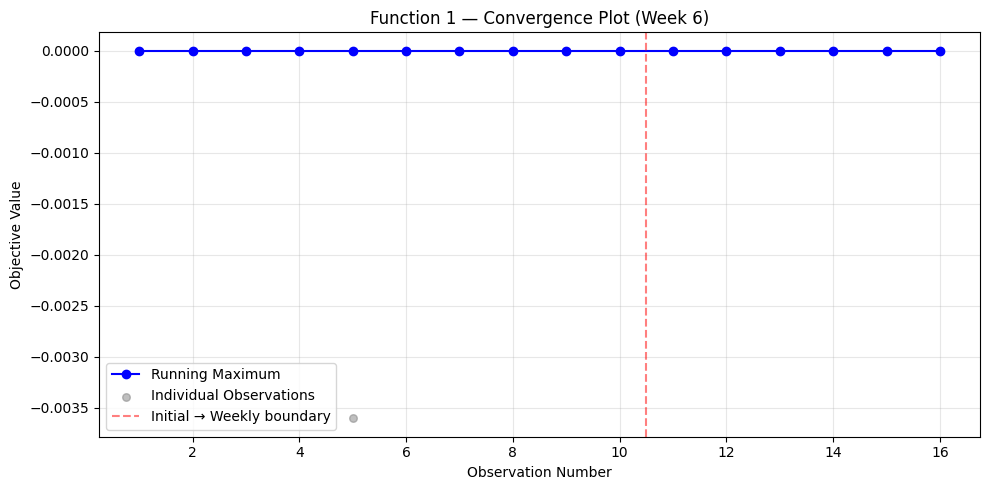

Best observed value: 7.710875e-16
Achieved at observation: 3


In [14]:
# Convergence plot: running maximum over all observations
running_max = np.maximum.accumulate(y_w6)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w6) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w6) + 1), y_w6, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 1 — Convergence Plot (Week 6)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w6.max():.6e}")
print(f"Achieved at observation: {y_w6.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point in the required submission format: `x1-x2` with 6 decimal places, clamped to [0.0, 1.0].

In [15]:
# Format submission query
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0.0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w6 = format_query(next_point_w6)

print("=" * 60)
print("WEEK 6 SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"Surrogate: Polynomial Response Surface (Quadratic)")
print(f"Acquisition: UCB (κ={KAPPA})")
print(f"Strategy: EXPLORATION (κ doubled from 1.5 to 3.0)")
print(f"Next point: [{next_point_w6[0]:.6f}, {next_point_w6[1]:.6f}]")
print(f"Polynomial prediction at next point: {mu[best_idx]:.6e}")
print(f"Distance-based uncertainty: {sigma[best_idx]:.6f}")
print(f"UCB value: {ucb[best_idx]:.6f}")
print(f"\n>>> SUBMISSION: {submission_query_w6}")
print("=" * 60)

WEEK 6 SUBMISSION QUERY FOR FUNCTION 1
Surrogate: Polynomial Response Surface (Quadratic)
Acquisition: UCB (κ=3.0)
Strategy: EXPLORATION (κ doubled from 1.5 to 3.0)
Next point: [0.004402, 0.000330]
Polynomial prediction at next point: 7.349778e-04
Distance-based uncertainty: 1.000000
UCB value: 3.940561

>>> SUBMISSION: 0.004402-0.000330


# Research into Problem - CoPilot
Below is a **practical, competition-grade Bayesian Optimization (BO) recipe** for your NeurIPS‑style “contamination/radiation source localization” task in **2D** where readings are **exactly zero unless you get close enough** (i.e., a **large flat/zero region + localized spikes**). That structure is *precisely* where plain GP‑EI often struggles to converge.

I’ll give you:

1.  **Recommended surrogate model (best default + alternatives)**
2.  **Acquisition function (best default + why)**
3.  **Suggested hyperparameters** (with sensible priors / initial values)
4.  **A robust “strong + weak sources” strategy** (multi-peak, avoid getting stuck)

***

## 1) Problem characteristics (why standard GP often fails)

Your objective surface is typically:

*   **Non-smooth / piecewise** (hard threshold: zero outside proximity radius)
*   **Highly non-stationary** (tiny hot regions + broad flats)
*   Often **zero-inflated / count-like** (radiation counts are Poisson; “no event → 0”)
*   **Multi-modal** (multiple sources, weak ones get overshadowed)

These conditions are explicitly called out in the surrogate modeling literature as scenarios where **GPs with standard stationary kernels can be fragile**, and where **adaptive/tree-based Bayesian surrogates** are often more robust. For example, Bayesian additive regression trees (BART) and adaptive splines are proposed specifically to handle **non-smooth patterns** better than GP surrogates. [\[nature.com\]](https://www.nature.com/articles/s41524-021-00662-x.pdf)

Also, for contamination-source identification problems, a published BO study found **RF surrogate + UCB acquisition** to be the most **efficient and reliable** across scenarios compared to GP+EI/PI/UCB variants. [\[mdpi.com\]](https://www.mdpi.com/2073-4441/16/1/168), [\[par.nsf.gov\]](https://par.nsf.gov/servlets/purl/10562965)

***

## 2) Best “default” surrogate model for this task

### ✅ Recommended baseline: **BART (Bayesian Additive Regression Trees)** surrogate

**Why:**

*   Handles **sharp discontinuities / plateaus** naturally
*   Provides **usable uncertainty** (posterior over trees)
*   Works well in **low‑D (2D)** and **multi-modal** landscapes
*   Often outperforms GP when the objective is **non-smooth** [\[nature.com\]](https://www.nature.com/articles/s41524-021-00662-x.pdf)

If BART is not available in your stack, use the next best:

### ✅ Practical alternative: **Random Forest (RF) surrogate with uncertainty**

RF is a strong workhorse for “spiky + flat” fields and is empirically strong for source identification BO; the contamination-source BO study found **RF + UCB** gave the best efficiency/reliability. [\[mdpi.com\]](https://www.mdpi.com/2073-4441/16/1/168), [\[par.nsf.gov\]](https://par.nsf.gov/servlets/purl/10562965)

> **Summary choice:**  
> **BART** if you can. Otherwise **RF**.

***

## 3) Acquisition function (what works best here)

### ✅ Recommended baseline: **UCB / GP-UCB style exploration**

Use **Upper Confidence Bound (UCB)** with a **high exploration weight early**, then anneal down.

**Why UCB beats EI/PI here:**

*   In big flat zero regions, EI often sees “no improvement anywhere” (or noisy gradients) and becomes brittle.
*   UCB forces systematic exploration even when mean predictions are flat—critical when non-zero readings occur only in tiny regions.
*   Empirically, RF+UCB was the most reliable in contamination-source BO experiments. [\[mdpi.com\]](https://www.mdpi.com/2073-4441/16/1/168), [\[par.nsf.gov\]](https://par.nsf.gov/servlets/purl/10562965)

### If your real goal is “find sources” rather than “maximize intensity”

The task is closer to **active search / information gain** than classic BO. If you stay with BO, add a **two-phase acquisition**:

1.  **Discovery phase:** maximize probability of *non-zero detection* (finding any source)
2.  **Refinement phase:** maximize intensity / improve localization

I’ll show how to implement this with the surrogate below.

***

## 4) The most robust model for “zero unless close”: a **two-part (hurdle) surrogate** (optional but excellent)

If you want something that matches the physics of “zero unless close,” use a **hurdle model**:

*   **Model A (classification):** $$p(x) = P(y>0 \mid x)$$
*   **Model B (regression):** $$g(x) = \mathbb{E}[\log(1+y) \mid y>0, x]$$

Then predicted expected signal is:

$$
\mu_y(x) \approx p(x)\cdot \exp(\mu_g(x)) - 1
$$

This is more work than RF/BART alone, but it’s the cleanest way to handle **zero inflation**.

**Surrogate choice for each head:**

*   Classifier: **GP classifier** or **tree classifier (BART/RF)**
*   Regressor: **BART/RF** on $$\log(1+y)$$

***

# 5) Suggested hyperparameters (ready-to-use defaults)

Below are *good defaults* for your specific setting: 2D, sparse positives, strong + weak sources.

***

## A) **BART surrogate hyperparameters**

Typical robust starting values:

*   **n\_trees:** 200
*   **tree depth prior:** shallow trees favored (controls overfitting)
*   **alpha/beta (tree structure prior):**
    *   alpha = 0.95
    *   beta = 2
*   **y-transform:**
    *   use `log1p(y)` before fitting (stabilizes huge intensity differences)

**Why these:** A higher number of shallow trees models complex shapes while retaining smooth uncertainty estimates; BART is recommended for non-smooth objectives in BO contexts. [\[nature.com\]](https://www.nature.com/articles/s41524-021-00662-x.pdf)

***

## B) **RF surrogate hyperparameters (with uncertainty)**

Use RF with either:

*   **Quantile Regression Forest**, or
*   **Ensemble variance** as uncertainty, or
*   **Jackknife / infinitesimal jackknife** (if supported)

Suggested settings:

*   **n\_estimators:** 500 (1000 if cheap)
*   **max\_features:** 1 or 2 (since d=2; keep trees diverse)
*   **min\_samples\_leaf:** 2–5 (reduces overfit to sparse spikes)
*   **bootstrap:** True
*   **criterion:** squared\_error (regression)
*   **target transform:** `log1p(y)`

RF+UCB is supported as a reliable choice in contamination/source BO experiments. [\[mdpi.com\]](https://www.mdpi.com/2073-4441/16/1/168), [\[par.nsf.gov\]](https://par.nsf.gov/servlets/purl/10562965)

***

## C) **UCB acquisition hyperparameters**

Define:

$$
\text{UCB}(x) = \mu(x) + \kappa_t \sigma(x)
$$

Recommended schedule for $$\kappa_t$$ in sparse detection:

*   **Exploration-heavy early:** $$\kappa_0 = 2.5$$ to **3.5**
*   **Anneal down:** linear or exponential decay to $$\kappa_T \approx 0.7$$

Example schedule over $$T$$ iterations:

$$
\kappa_t = \max(0.7,\ 3.0 \cdot (0.97)^t)
$$

This avoids getting stuck exploiting early weak signals and helps you “hit” the first non-zero region sooner.

***

## D) Batch selection (recommended in practice)

If you can query multiple points per iteration:

*   Use **qUCB** (pick top‑q points by UCB with local penalization)
*   Add **diversity penalty** so points spread out (critical for finding multiple sources)

***

# 6) Multi-source strategy (strong + weak source discovery)

To reliably find **both strong and weak** sources, do **sequential deconfounding**:

### Phase 1 — Discover any source quickly

*   Run **UCB with high $$\kappa$$**
*   Goal: find first non-zero region

### Phase 2 — Lock onto peak and estimate its “influence radius”

Once you see consistent non-zero readings:

*   Switch to **lower $$\kappa$$** (more exploitation)
*   Fit a local model around the hotspot to estimate source location & strength

### Phase 3 — Suppress the discovered source and continue searching

To avoid the strong source dominating:

*   Add a **local penalization mask** around the found source:
    *   penalize acquisitions within radius $$r_{mask}$$ (e.g., 2–3× estimated detection radius)
*   Continue BO in the remaining space to find weaker peaks

This idea is closely aligned with “local BO / space partitioning” approaches used successfully in low-budget black-box competitions (partition + local BO). [\[proceeding....mlr.press\]](https://proceedings.mlr.press/v133/sazanovich21a.html), [\[arxiv.org\]](https://arxiv.org/pdf/2012.10335v1)

***

# 7) Concrete “best practice” configuration (my recommended answer)

If you want one clean answer:

## ✅ Best overall pick (robust + simple)

*   **Surrogate:** **Random Forest** (on `log1p(y)`) with uncertainty from ensemble variance / quantiles [\[mdpi.com\]](https://www.mdpi.com/2073-4441/16/1/168), [\[par.nsf.gov\]](https://par.nsf.gov/servlets/purl/10562965)
*   **Acquisition:** **UCB** with annealed $$\kappa_t$$
*   **Hyperparameters:**
    *   RF: `n_estimators=500`, `min_samples_leaf=3`, `max_features=1`
    *   UCB: start $$\kappa=3.0$$, decay to \~0.7
    *   Batch: qUCB + diversity penalty (if parallel)

## ✅ If you can afford more sophistication (best modeling fidelity)

*   **Surrogate:** **Hurdle model**
    *   classifier for $$P(y>0)$$ + regressor for `log1p(y) | y>0`
*   **Acquisition:** **weighted UCB**:
    $$
    a(x)=p(x)\cdot\mu(x) + \kappa\cdot\sqrt{\text{Var}(p(x)\mu(x))}
    $$
*   **Plus:** local penalization to find multiple sources

***

# 8) One (optional) follow-up that would let me tune these precisely

To tailor the hyperparameters optimally, what is your **evaluation budget** and **detection radius / proximity threshold** (even approximate)?

*   e.g., “\~200 queries total, non-zero within \~5m”

Those two numbers determine the best initial $$\kappa$$, exploration schedule, and kernel/leaf-size defaults.
